In [1]:
# local library
from propagation import (
    KemenyYoung,
    lpa,
    run_label_propagation,
    set_labels,
)
# python libraries
import pandas as pd
import numpy as np
import networkx as nx
from typing import Any
import matplotlib.pyplot as plt
from collections import Counter
#import random
#from joblib import Parallel, delayed
#import community.community_louvain as community_louvain
import upsetplot
#import matplotlib.patches as mpatches


In [2]:
from pathlib import Path

project_root = Path.cwd()
data_folder = project_root / "data"
graph_path = data_folder / "modified_graph.gml"
results_folder = project_root / "results"

print("Project root:", project_root)
print("Data directory:", data_folder)
print("Results directory:", results_folder)

Project root: /home/scostagonza/Documents/LPA-KY/LPA-Kemeny-Young
Data directory: /home/scostagonza/Documents/LPA-KY/LPA-Kemeny-Young/data
Results directory: /home/scostagonza/Documents/LPA-KY/LPA-Kemeny-Young/results


In [3]:
G = nx.read_gml(graph_path)
print("Number of nodes in the graph:", G.number_of_nodes())
print("Number of edges in the graph:", G.number_of_edges())

Number of nodes in the graph: 3240
Number of edges in the graph: 7254


In [4]:
# Load, filter, and prepare experiment data
data_folder = Path.cwd() / "data"
data_files = {
    "liu": data_folder / "liu.txt",
    "gonzalez": data_folder / "gonzalez.txt",
    "comets": data_folder / "COMETS.txt",
    "mth": data_folder / "MTH.txt",
    "pietzner": data_folder / "pietznzer.txt",
    "estelle": data_folder / "Estelle.txt",
}

valid_nodes = set(G.nodes())
experiments = []

for name, file_path in data_files.items():
    data_list = pd.read_csv(file_path).HUMAN1_ID.tolist()
    filtered_list = [node for node in data_list if node in valid_nodes]
    print(f"{name.capitalize()}: {len(filtered_list)}/{len(data_list)} nodes valid")
    experiments.append((name, filtered_list))

Liu: 263/1002 nodes valid
Gonzalez: 241/902 nodes valid
Comets: 204/827 nodes valid
Mth: 176/682 nodes valid
Pietzner: 190/760 nodes valid
Estelle: 420/1527 nodes valid


In [5]:
# Define a function that runs label propagation for each dataset
def run_experiment(name, exp_list):
    result = run_label_propagation(G, exp_list)
    return name, result  # Return the name and the result for easier tracking

def initial_labels(name,exp_list):
    result = set_labels(G, exp_list)
    return name, result  # Return the name and the result for easier tracking

In [6]:
# Set labels for each dataset
initial = [initial_labels(name, exp_list) for name, exp_list in experiments]
# Run label propagation for each dataset
results = [run_experiment(name, exp) for name, exp in experiments]

In [7]:
results_dict = {name: result for name, result in results}
initial_dict = {name: result for name, result in initial}

In [ ]:
# Extract experiment names and propagated label dictionaries
experiment_names = [
    name
    for name, _ in results
]

results_lpa = [
    propagated_labels
    for _, propagated_labels in results
]

initial_labels = [
    initial_labels 
    for _, initial_labels in initial
]

,Experiment,Initial count,After LPA
0,liu,263,549
1,gonzalez,241,473
2,comets,204,402
3,mth,176,342
4,pietzner,190,379
5,estelle,420,809


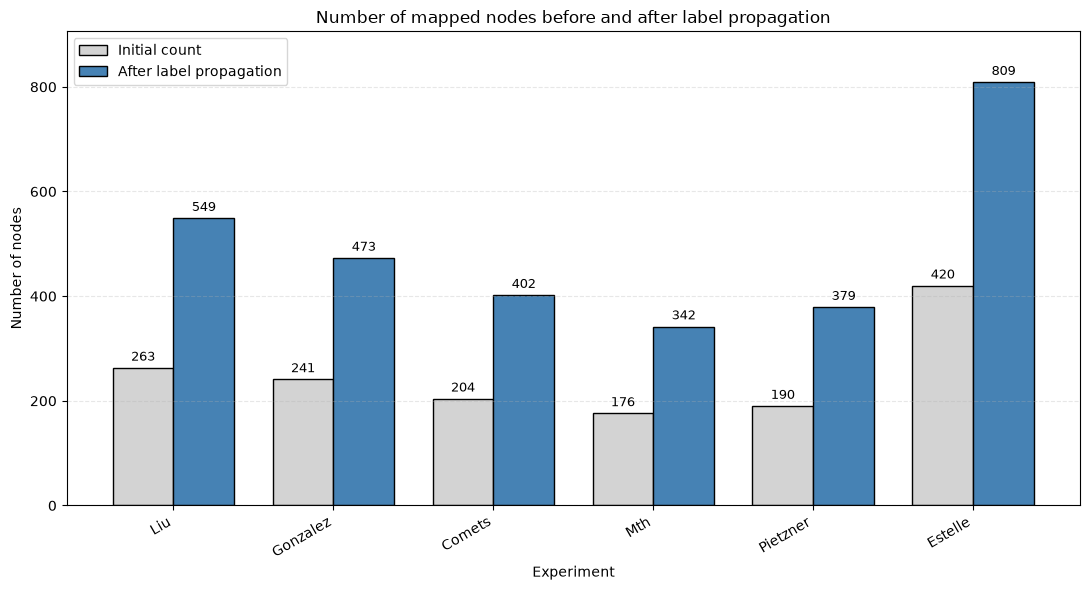

In [9]:
# Preserve the order used in the experiments list
experiment_names = [name for name, _ in experiments]

# Counts before LPA: number of valid/mapped nodes in each experiment
initial_counts = [
    len(experimental_nodes)
    for _, experimental_nodes in experiments
]

# Counts after LPA: number of nodes assigned label 1
propagated_counts = [
    sum(results_dict[name].values())
    for name in experiment_names
]

# Optional summary table
count_summary = pd.DataFrame(
    {
        "Experiment": experiment_names,
        "Initial count": initial_counts,
        "After LPA": propagated_counts,
    }
)

display(count_summary)

# Positions of the experiment groups
x = np.arange(len(experiment_names))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))

initial_bars = ax.bar(
    x - bar_width / 2,
    initial_counts,
    width=bar_width,
    label="Initial count",
    color="lightgray",
    edgecolor="black",
)

propagated_bars = ax.bar(
    x + bar_width / 2,
    propagated_counts,
    width=bar_width,
    label="After label propagation",
    color="steelblue",
    edgecolor="black",
)

# Add the value above every bar
ax.bar_label(
    initial_bars,
    labels=[str(value) for value in initial_counts],
    padding=3,
    fontsize=9,
)

ax.bar_label(
    propagated_bars,
    labels=[str(value) for value in propagated_counts],
    padding=3,
    fontsize=9,
)

ax.set_xlabel("Experiment")
ax.set_ylabel("Number of nodes")
ax.set_title(
    "Number of mapped nodes before and after label propagation"
)

ax.set_xticks(x)
ax.set_xticklabels(
    [name.capitalize() for name in experiment_names],
    rotation=30,
    ha="right",
)

ax.legend()
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

# Add enough space above the largest bar for the labels
maximum_count = max(initial_counts + propagated_counts)
ax.set_ylim(0, maximum_count * 1.12)

fig.tight_layout()


plt.savefig(
    project_root / "results" / "LPA_counts_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [10]:
ky = KemenyYoung(G)

better_covered = ky.first_selected_candidate(
    candidate_list=results_lpa,
    candidate_names=experiment_names
)

better_covered_nonlpa = ky.first_selected_candidate(
    candidate_list=initial_labels, 
    candidate_names=experiment_names
)

,Experiment,Before LPA,After LPA
0,liu,263,549
1,gonzalez,241,473
2,comets,204,402
3,mth,176,342
4,pietzner,190,379
5,estelle,420,809


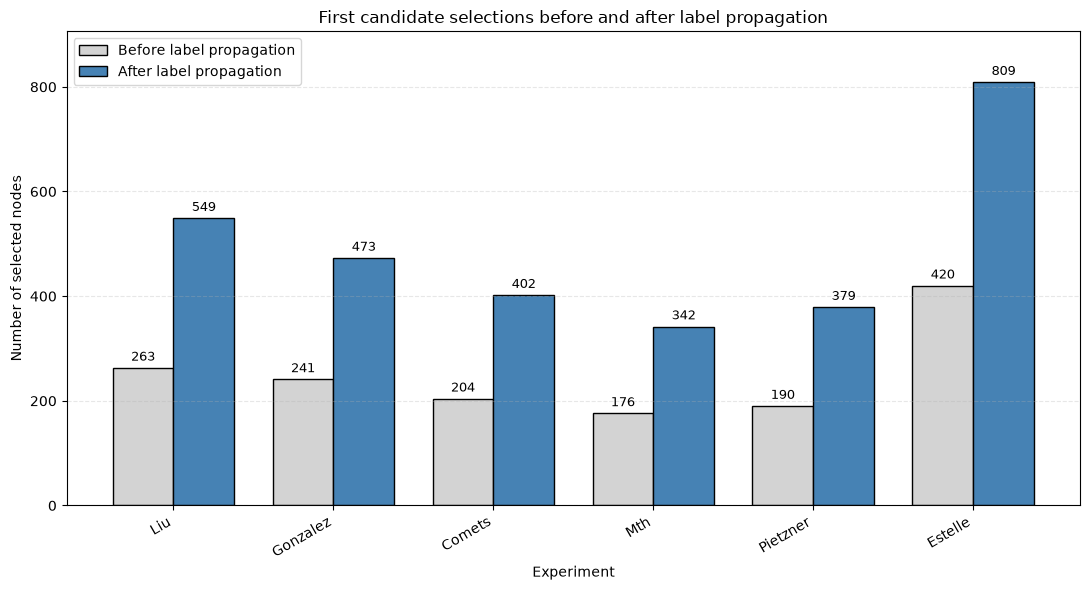

In [11]:
# Flatten candidate selections before LPA
flattened_nonlpa = [
    item
    for sublist in better_covered_nonlpa
    for item in sublist
]

# Flatten candidate selections after LPA
flattened_lpa = [
    item
    for sublist in better_covered
    for item in sublist
]

# Count how many times each experiment was selected
counter_nonlpa = Counter(flattened_nonlpa)
counter_lpa = Counter(flattened_lpa)

# Keep the same experiment order and include experiments with zero selections
selection_counts_nonlpa = [
    counter_nonlpa.get(name, 0)
    for name in experiment_names
]

selection_counts_lpa = [
    counter_lpa.get(name, 0)
    for name in experiment_names
]

# Summary table
selection_summary = pd.DataFrame(
    {
        "Experiment": experiment_names,
        "Before LPA": selection_counts_nonlpa,
        "After LPA": selection_counts_lpa,
    }
)

display(selection_summary)

# Positions of the experiment groups
x = np.arange(len(experiment_names))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))

before_bars = ax.bar(
    x - bar_width / 2,
    selection_counts_nonlpa,
    width=bar_width,
    label="Before label propagation",
    color="lightgray",
    edgecolor="black",
)

after_bars = ax.bar(
    x + bar_width / 2,
    selection_counts_lpa,
    width=bar_width,
    label="After label propagation",
    color="steelblue",
    edgecolor="black",
)

# Add values above every bar
ax.bar_label(
    before_bars,
    labels=[
        str(value)
        for value in selection_counts_nonlpa
    ],
    padding=3,
    fontsize=9,
)

ax.bar_label(
    after_bars,
    labels=[
        str(value)
        for value in selection_counts_lpa
    ],
    padding=3,
    fontsize=9,
)

ax.set_xlabel("Experiment")
ax.set_ylabel("Number of selected nodes")

ax.set_title(
    "First candidate selections before and after label propagation"
)

ax.set_xticks(x)

ax.set_xticklabels(
    [
        name.capitalize()
        for name in experiment_names
    ],
    rotation=30,
    ha="right",
)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

# Add enough space above the largest bar
maximum_count = max(
    selection_counts_nonlpa
    + selection_counts_lpa
)

ax.set_ylim(
    0,
    maximum_count * 1.12
    if maximum_count > 0
    else 1,
)

fig.tight_layout()

plt.savefig(
    project_root
    / "results"
    / "first_selection_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()